# Applied Machine Learning

## Exploratory Data Analysis

In this notebook, we will go over the data for our project to obtain more insights about the distribution, features and classes for *Sleep EDF Database*. This EDA uses the **sleep stage annotations** found in the `-Hypnogram.edf` files. The analysis of features relevant to **arousal detection** requires the feature engineering step outlined in the project plan and the definitive arousal labels.

In [1]:
import os
import sys
import mne
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
logging.basicConfig(level=logging.WARNING)
mne.set_log_level("WARNING")

In [3]:
if 'utils' not in sys.path:
    sys.path.insert(0, 'utils')

try:
    from project_name.utils.load_data import load_sleep_data
    print("Utility functions imported successfully.")
except ImportError as e:
    print(f"Error while importing the utils/load_data.py: {e}")
    print("Make sure the file exists and 'utils' directory is in the Python path.")

Utility functions imported successfully.


In [4]:
DATA_DIR = './data'
MAX_SUBJECTS = 3
PRELOAD = False

if not os.path.isdir(DATA_DIR):
    print(f"ERROR: Data directory not found at {DATA_DIR}")
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")
else:
    print(f"Looking for data in: {os.path.abspath(DATA_DIR)}")
    
print(f"\n--- Loading SC Subjects (Max: {MAX_SUBJECTS}) ---")
all_cassette_data = load_sleep_data(DATA_DIR,
                                    subject_pattern="SC*",
                                    max_subjects=MAX_SUBJECTS,
                                    preload_data=PRELOAD)
print(f"Loaded {len(all_cassette_data)} SC subjects.")

print(f"\n--- Loading ST Subjects (Max: {MAX_SUBJECTS}) ---")
all_telemetry_data = load_sleep_data(DATA_DIR,
                                     subject_pattern="ST*",
                                     max_subjects=MAX_SUBJECTS,
                                     preload_data=PRELOAD)
print(f"Loaded {len(all_telemetry_data)} ST subjects.")

# combine the data
all_subject_data = all_cassette_data + all_telemetry_data

Looking for data in: /Users/mede/Applied-ML/data

--- Loading SC Subjects (Max: 3) ---
Loaded 3 SC subjects.

--- Loading ST Subjects (Max: 3) ---
Loaded 3 ST subjects.


/Users/mede/Applied-ML/project_name/utils/load_data.py:135: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, emit_warning=True)
/Users/mede/Applied-ML/project_name/utils/load_data.py:135: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, emit_warning=True)
/Users/mede/Applied-ML/project_name/utils/load_data.py:135: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, emit_warning=True)


In [6]:
for raw in all_subject_data:
    subject_id = raw.info.get('subject_info', {}).get('id', '')
    if subject_id.startswith('SC'):
        raw.info['subject_info']['group'] = 'SC'
    elif subject_id.startswith('ST'):
        raw.info['subject_info']['group'] = 'ST'
    else:
        raw.info['subject_info']['group'] = 'Unknown'

if not all_subject_data:
    print("\nNo data loaded. Please check the data_dir, max_subjects and file structure.")
    raise ValueError("Failed to load any subject data.")
else:
    print(f"\n--- Total subjects loaded: {len(all_subject_data)} ---")
    print("\nInfo for the first loaded subject:")
    print(all_subject_data[0].info)


--- Total subjects loaded: 6 ---

Info for the first loaded subject:
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: 2 items (dict)
>


In [8]:
all_channels = set()
all_sfreqs = set()
all_annotations_summary = {}

print("\n --- Inspecting Loaded Subjects ---")
for i, raw in enumerate(all_subject_data):
    subject_id = raw.info.get('subject_info', {}).get('id', f'Unknown_{i}')
    group = raw.info.get('subject_info', {}).get('group', '?')
    print(f"\nSubject {i+1}/{len(all_subject_data)}: {subject_id} (Group: {group})")

    print(f"Channels ({len(raw.ch_names)}): {raw.ch_names[:5]}...")
    all_channels.update(raw.ch_names)
    print(f"Sampling frequency: {raw.info['sfreq']} Hz")
    all_sfreqs.add(raw.info['sfreq'])
    print(f"Highpass: {raw.info['highpass']} Hz, Lowpass: {raw.info['lowpass']} Hz")

    print("Annotations present:")
    if raw.annotations is not None and len(raw.annotations) > 0:
        try:
            counts = pd.Series(raw.annotations.description).value_counts().sort_index()
            all_annotations_summary[subject_id] = counts
            for desc, count in counts.items():
                print(f" - {desc}: {count}")
        except Exception as e:
            print(f" Error getting annotations count: {e}")
            all_annotations_summary[subject_id] = pd.Series(dtype=int)
    else:
        print("No annotations found.")
        all_annotations_summary[subject_id] = pd.Series(dtype=int)


 --- Inspecting Loaded Subjects ---

Subject 1/6: SC4001E0 (Group: SC)
Channels (7): ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental']...
Sampling frequency: 100.0 Hz
Highpass: 0.5 Hz, Lowpass: 100.0 Hz
Annotations present:
 - Sleep stage 1: 24
 - Sleep stage 2: 40
 - Sleep stage 3: 48
 - Sleep stage 4: 23
 - Sleep stage ?: 1
 - Sleep stage R: 6
 - Sleep stage W: 12

Subject 2/6: SC4002E0 (Group: SC)
Channels (7): ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental']...
Sampling frequency: 100.0 Hz
Highpass: 0.5 Hz, Lowpass: 100.0 Hz
Annotations present:
 - Movement time: 1
 - Sleep stage 1: 32
 - Sleep stage 2: 37
 - Sleep stage 3: 30
 - Sleep stage 4: 16
 - Sleep stage ?: 1
 - Sleep stage R: 12
 - Sleep stage W: 23

Subject 3/6: SC4011E0 (Group: SC)
Channels (7): ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental']...
Sampling frequency: 100.0 Hz
Highpass: 0.5 Hz, Lowpass: 100.0 Hz
Annotations pres

In [9]:
print("\n--- Overall Summary ---")
print(f"Unique sampling frequencies found: {all_sfreqs}")
print(f"Total number of unique channel names across subjects: {len(all_channels)}")
print(f"All unique channel names: {sorted(list(all_channels))}")


--- Overall Summary ---
Unique sampling frequencies found: {100.0}
Total number of unique channel names across subjects: 7
All unique channel names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EMG submental', 'EOG horizontal', 'Event marker', 'Resp oro-nasal', 'Temp rectal']


In [22]:
try:
    mne.viz.set_browser_backend('matplotlib')
    print("MNE browser backend set to 'matplotlib'.")
except Exception as e_backend:
    print(f"Could not set MNE browser backend: {e_backend}")

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

MNE browser backend set to 'matplotlib'.



--- Plotting Raw Data Snippets ---

Plotting raw data for Subject: SC4001E0
Plotting channel indices: [0 1 2 4] corresponding to names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']


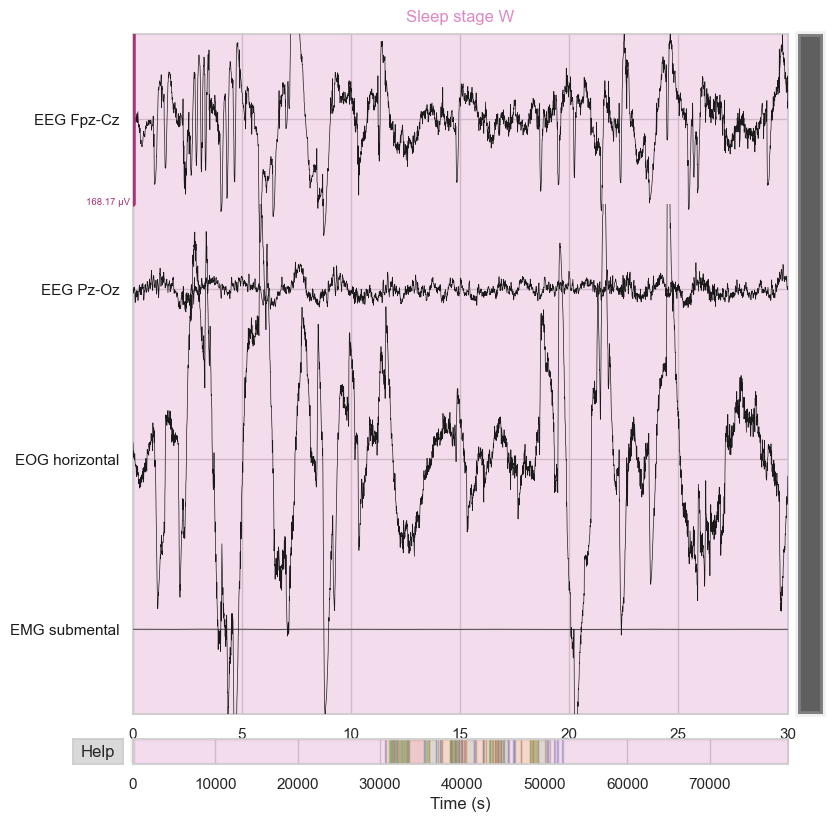


Plotting raw data for Subject: SC4002E0
Plotting channel indices: [0 1 2 4] corresponding to names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']


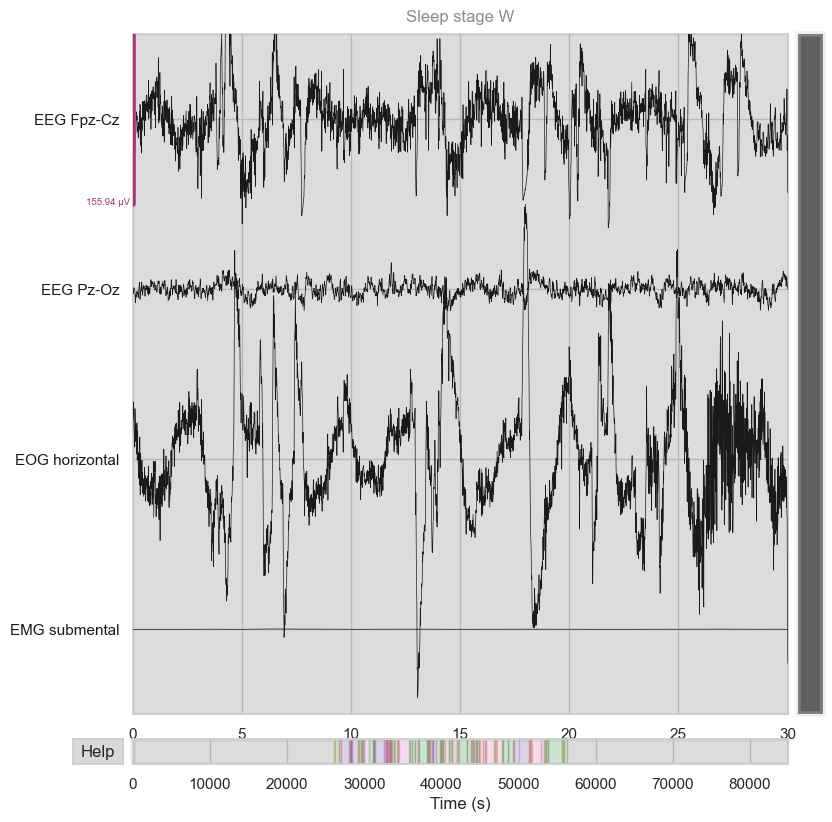


Plotting raw data for Subject: SC4011E0
Plotting channel indices: [0 1 2 4] corresponding to names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']


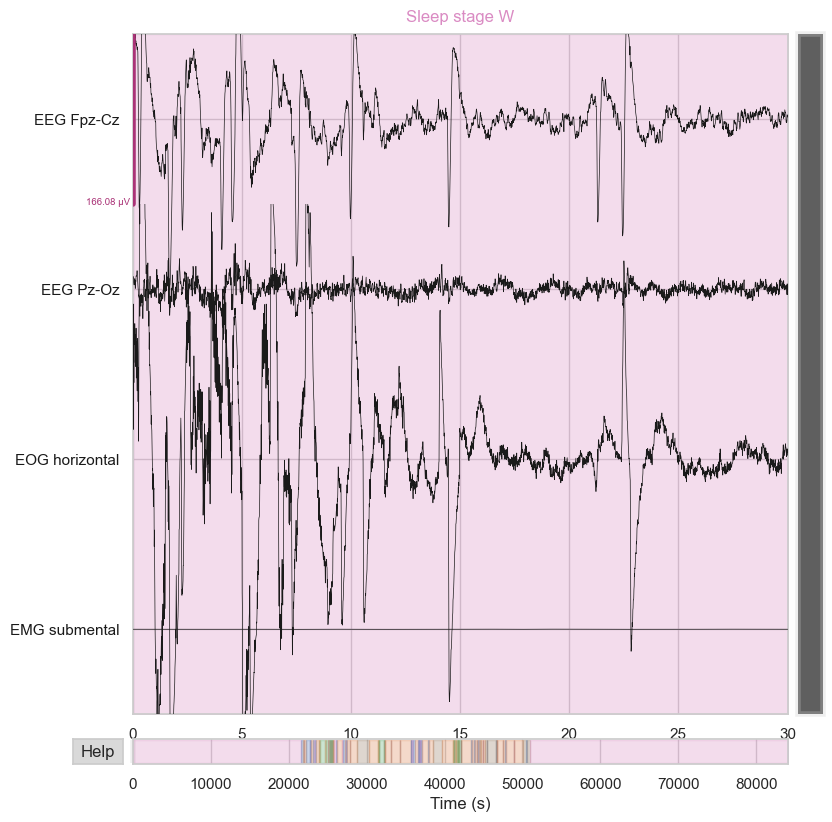


Plotting raw data for Subject: ST7011J0
Plotting channel indices: [0 1 2 3] corresponding to names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']


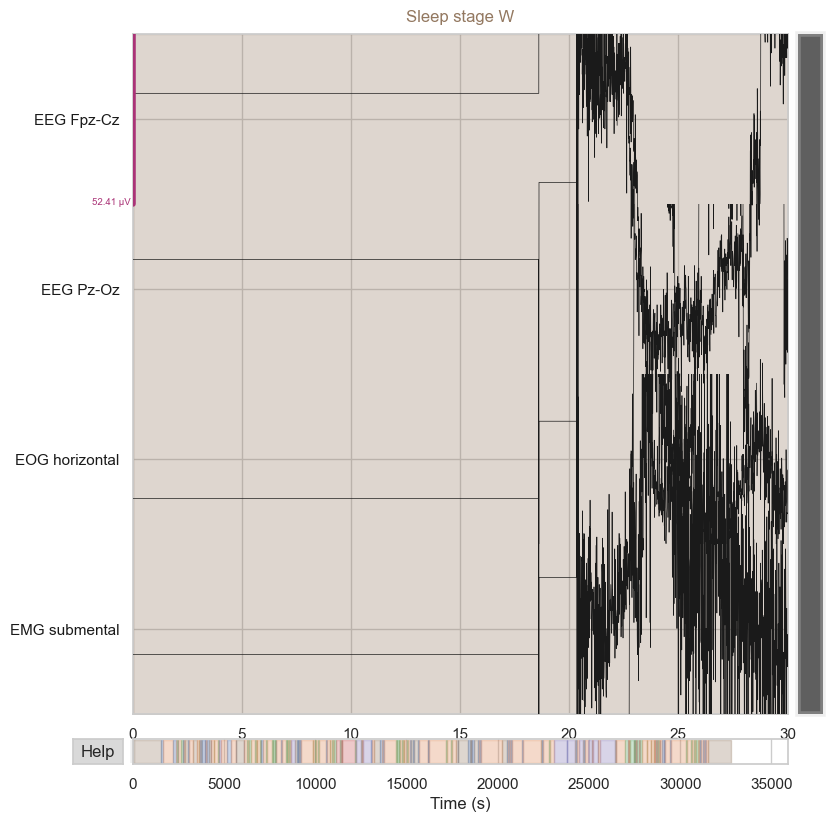


Plotting raw data for Subject: ST7012J0
Plotting channel indices: [0 1 2 3] corresponding to names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']


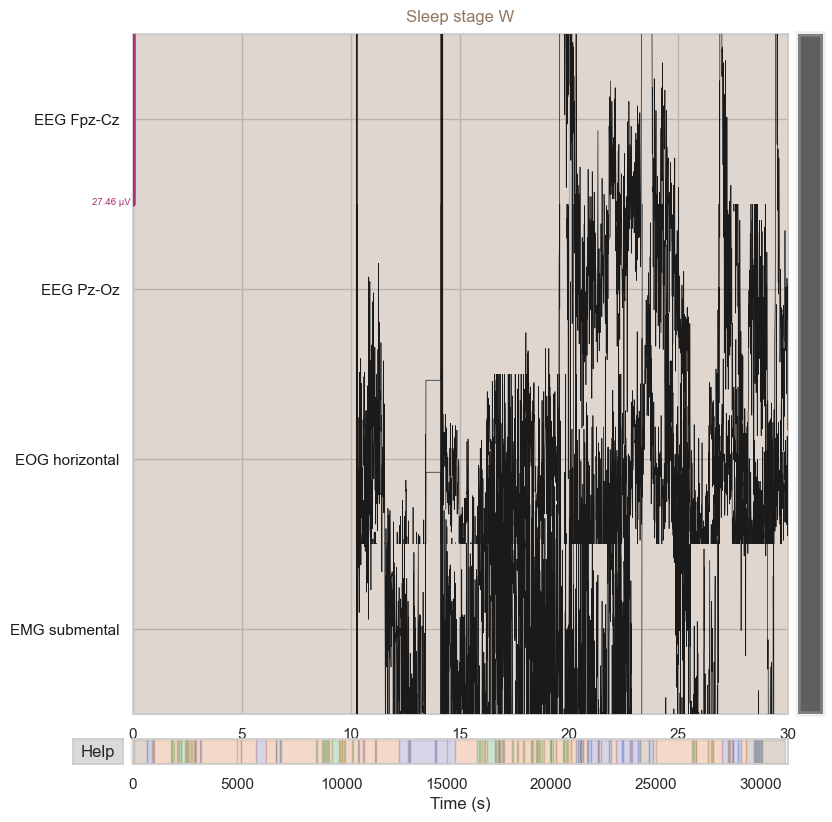


Plotting raw data for Subject: ST7021J0
Plotting channel indices: [0 1 2 3] corresponding to names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']


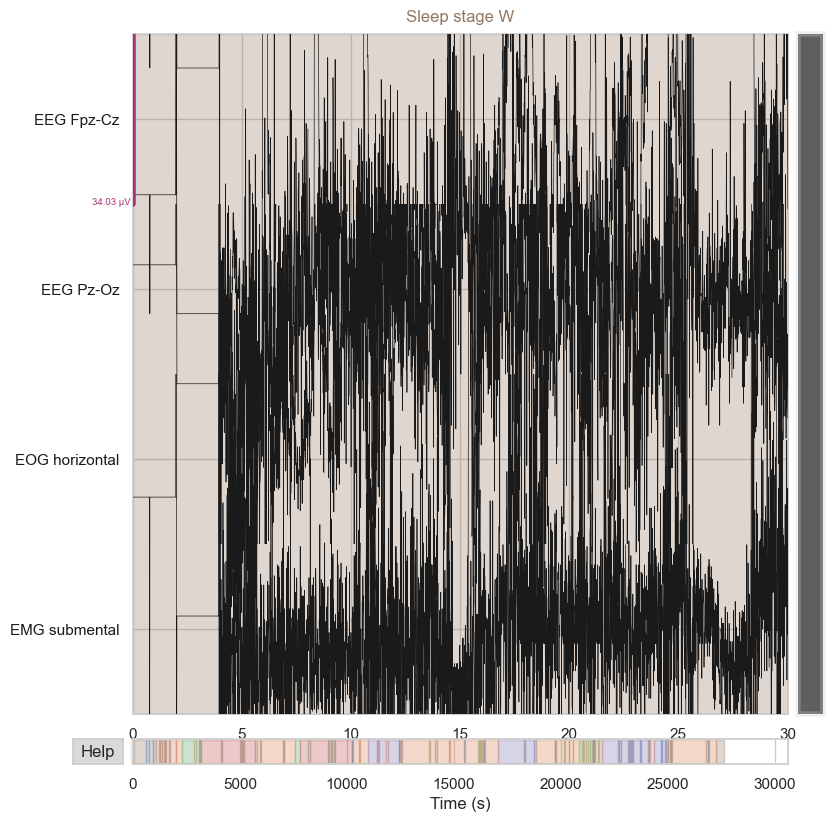

In [23]:
print("\n--- Plotting Raw Data Snippets ---")
duration_to_plot = 30
channels_to_plot = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']

for i, raw in enumerate(all_subject_data):
    subject_id = raw.info.get('subject_info', {}).get('id', f'Unknown_{i}')
    print(f"\nPlotting raw data for Subject: {subject_id}")

    if not raw.preload:
        print(f"Preloading data for {subject_id}...")
        try:
            raw.load_data()
            print("Data loaded.")
        except Exception as e:
            print(f"Error while loading data: {e}")
            continue

    channels_present = [ch for ch in channels_to_plot if ch in raw.ch_names]
    if not channels_present:
        channels_present = raw.ch_names[:min(4, len(raw.ch_names))]
    
    if not channels_present:
        print(f"No channels found to plot for {subject_id}. Skipping raw plot.")
        continue

    # get channel indices
    try:
        channel_indices = mne.pick_channels(raw.ch_names, include=channels_present, ordered=True)
        if len(channels_present) == 0:
            print(f"Could not pick channels for {subject_id} using names: {channels_present}. Skipping raw plot.")
            continue
        print(f"Plotting channel indices: {channel_indices} corresponding to names: {channels_present}")
    except Exception as e_pick:
         print(f"Error picking channels for {subject_id}: {e_pick}. Skipping raw plot.")
         continue

    try:
        plot_fig = raw.plot(duration=duration_to_plot,
                            order=channel_indices,
                            n_channels=len(channels_present),
                            scalings='auto',
                            show=False,
                            title=f'Raw Data Snippet - Subject {subject_id}',
                            block=False
                            )
        plt.show()
    except Exception as e_plot:
        print(f"Error while plotting: {e_plot}")
        plt.close('all')


--- Plotting Power Spectral Densities (PSD) ---

Plotting PSD for Subject: SC4001E0


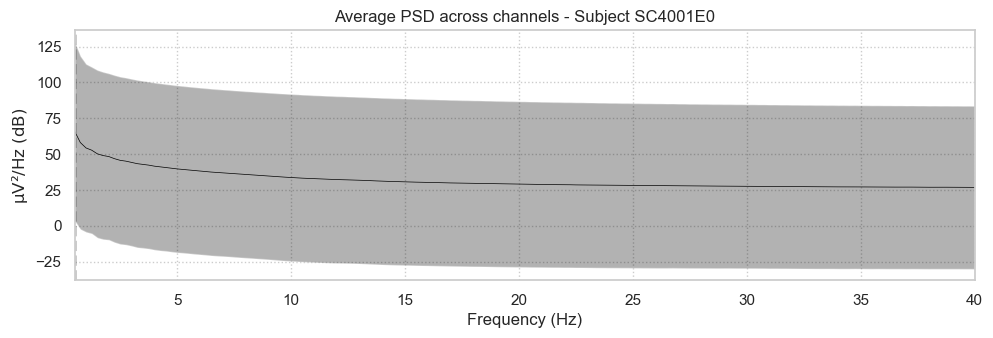


Plotting PSD for Subject: SC4002E0


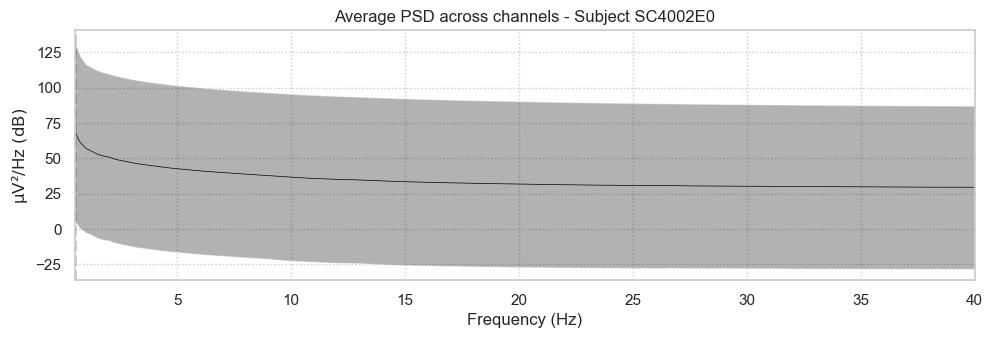


Plotting PSD for Subject: SC4011E0


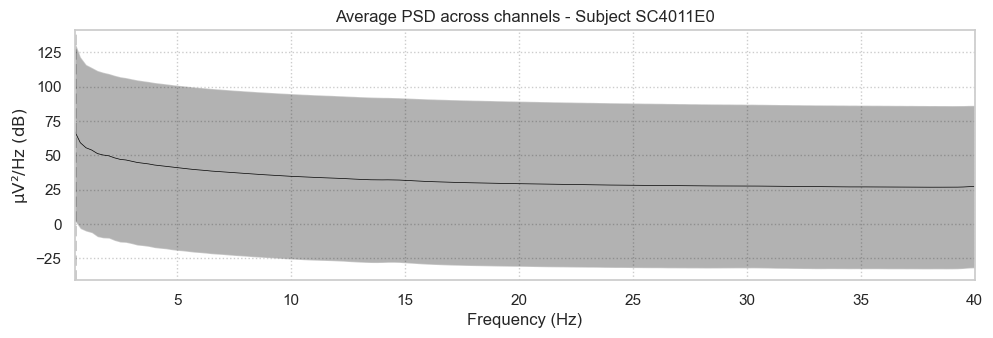


Plotting PSD for Subject: ST7011J0


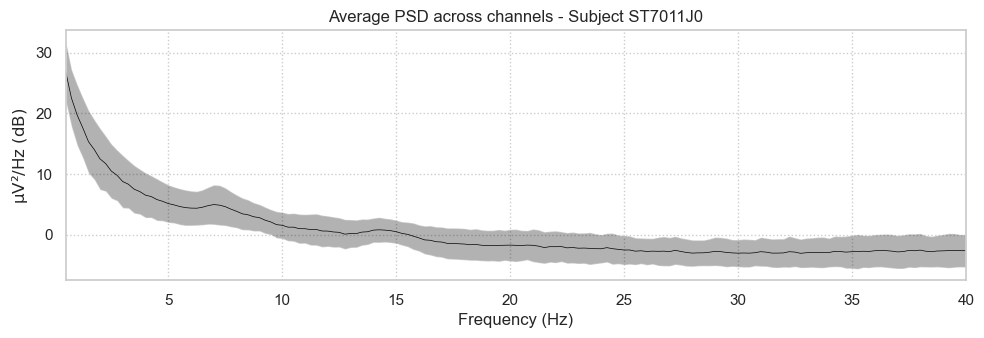


Plotting PSD for Subject: ST7012J0


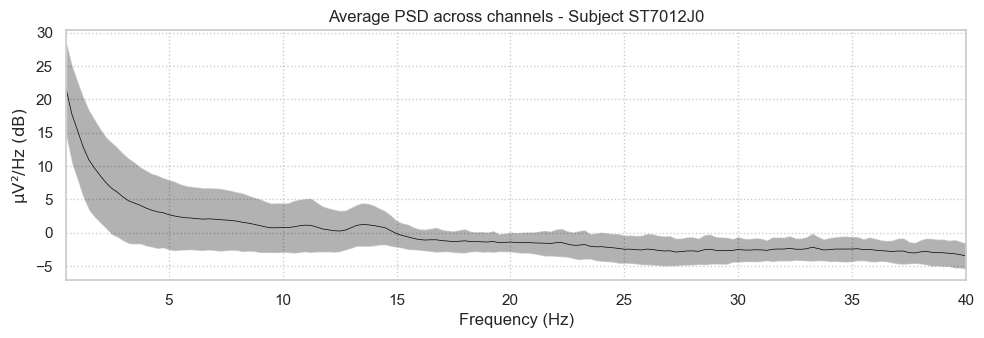


Plotting PSD for Subject: ST7021J0


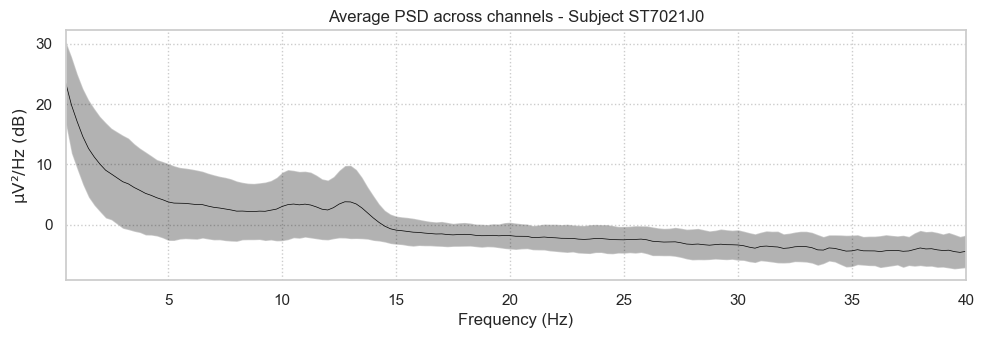

In [24]:
print("\n--- Plotting Power Spectral Densities (PSD) ---")
n_fft_seconds = 4
fmin = 0.5
fmax = 40

for i, raw in enumerate(all_subject_data):
    subject_id = raw.info.get('subject_info', {}).get('id', f'Unknown_{i}')
    print(f"\nPlotting PSD for Subject: {subject_id}")

    if not raw.preload:
        print(f"Preloading data for {subject_id}...")
        try:
            raw.load_data()
            print("Data loaded.")
        except Exception as e:
            print(f"Error while loading the data for {subject_id}: {e}")
            continue

    sfreq = raw.info['sfreq']
    n_fft = int(n_fft_seconds * sfreq)

    try:
        psd_computation = raw.compute_psd(method='welch', n_fft=n_fft, n_overlap=n_fft // 2, fmin=fmin, fmax=fmax)
        psd_figs = psd_computation.plot(average=True, spatial_colors=True, show=False)
        plt.title(f'Average PSD across channels - Subject {subject_id}')
        plt.show()
    except Exception as e:
        print(f"Error while plotting PSD for {subject_id}: {e}")
        plt.close('all')


--- Plotting Amplitude Distributions ---

Plotting amplitude distribution for Subject: SC4001E0


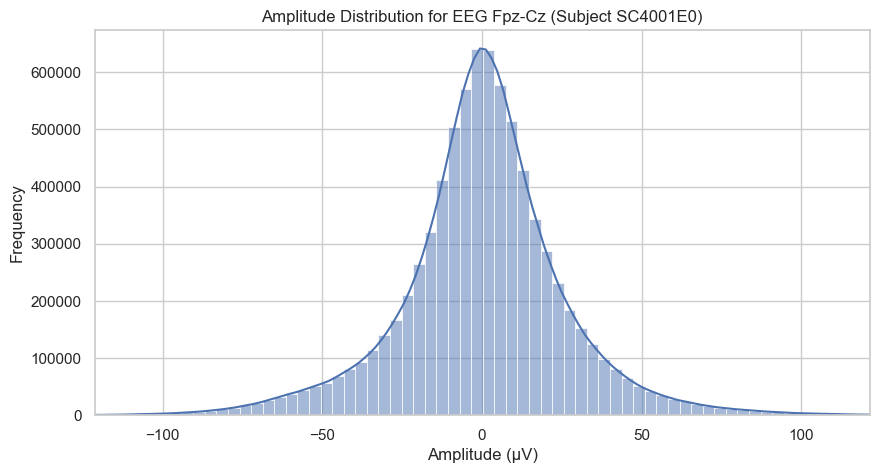

Basic stats for EEG Fpz-Cz: Mean=0.17 miuV, StdDev=25.91 miuV
Min=-192.00 miuV, Max=170.62 µV

Plotting amplitude distribution for Subject: SC4002E0


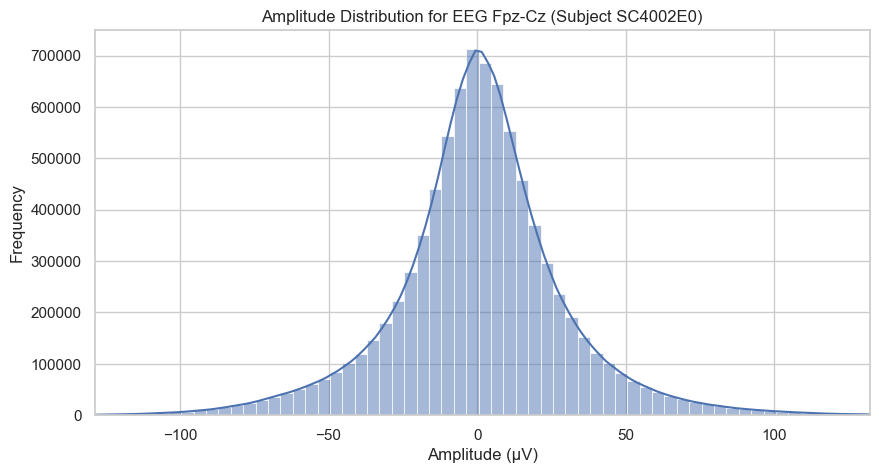

Basic stats for EEG Fpz-Cz: Mean=0.67 miuV, StdDev=29.04 miuV
Min=-208.00 miuV, Max=209.00 µV

Plotting amplitude distribution for Subject: SC4011E0


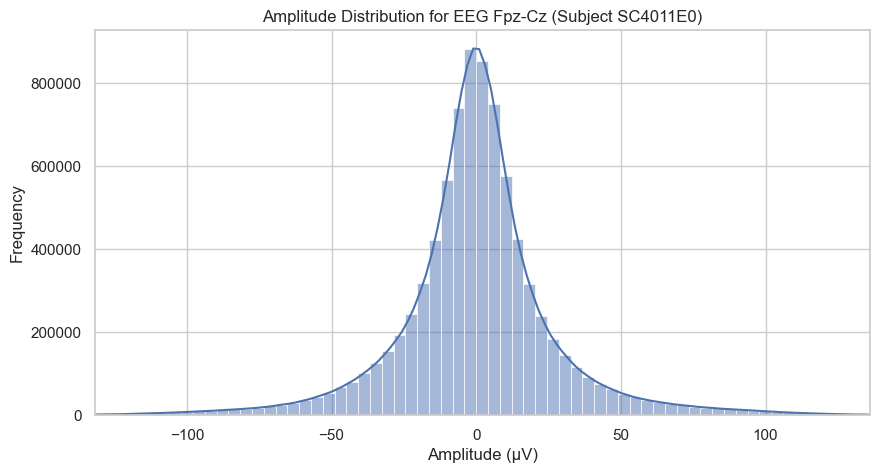

Basic stats for EEG Fpz-Cz: Mean=0.10 miuV, StdDev=27.55 miuV
Min=-204.00 miuV, Max=204.00 µV

Plotting amplitude distribution for Subject: ST7011J0


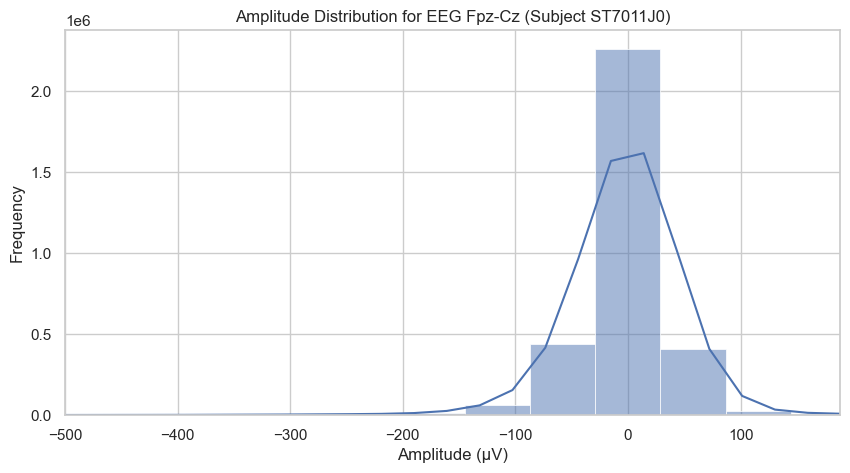

Basic stats for EEG Fpz-Cz: Mean=-205.66 miuV, StdDev=669.65 miuV
Min=-2812.49 miuV, Max=2986.08 µV

Plotting amplitude distribution for Subject: ST7012J0


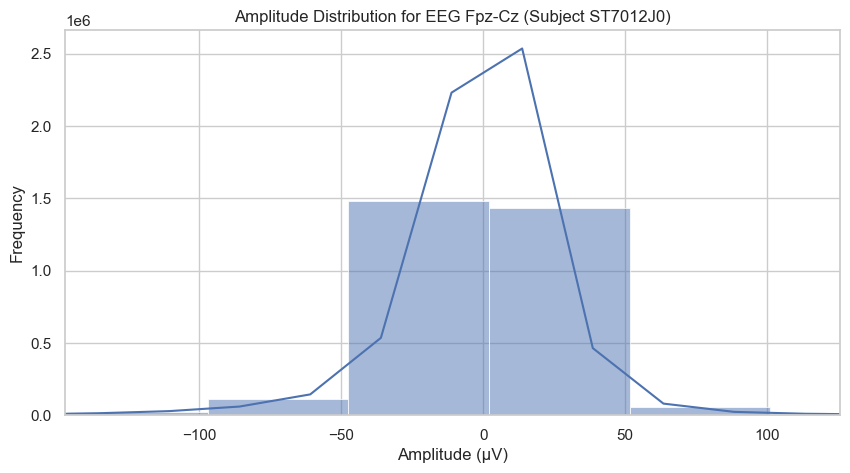

Basic stats for EEG Fpz-Cz: Mean=0.25 miuV, StdDev=43.82 miuV
Min=-2324.30 miuV, Max=2625.34 µV

Plotting amplitude distribution for Subject: ST7021J0


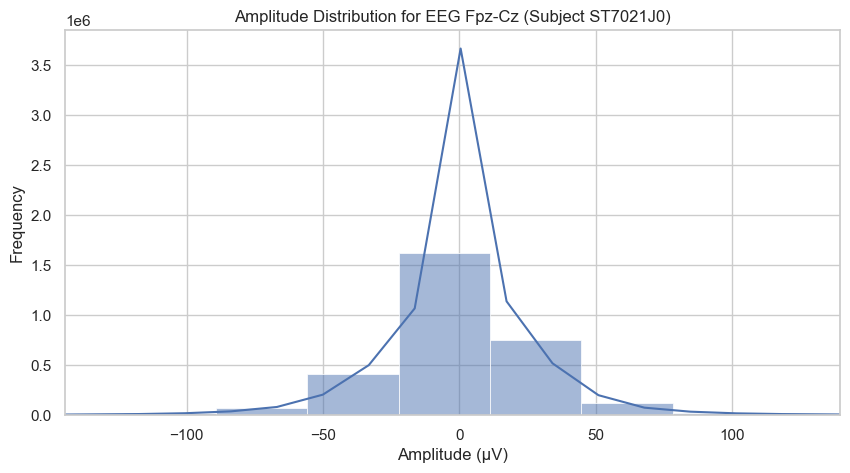

Basic stats for EEG Fpz-Cz: Mean=0.12 miuV, StdDev=35.44 miuV
Min=-1195.57 miuV, Max=2156.56 µV


In [25]:
print("\n--- Plotting Amplitude Distributions ---")

for i, raw in enumerate(all_subject_data):
    subject_id = raw.info.get('subject_info', {}).get('id', f'Unknown_{i}')
    print(f"\nPlotting amplitude distribution for Subject: {subject_id}")

    eeg_channel_name = None
    for ch_name in raw.ch_names:
        if 'EEG' in ch_name.upper():
            eeg_channel_name = ch_name
            break

    if eeg_channel_name:
        if not raw.preload:
             print(f"Preloading data for {subject_id}...")
             try:
                 raw.load_data()
                 print("  Data preloaded.")
             except Exception as e:
                 print(f"Error preloading data for {subject_id}: {e}. Skipping amplitude plot.")
                 continue

        try:
            eeg_data, _ = raw[eeg_channel_name, :]
            eeg_data_uV = eeg_data.flatten() * 1e6

            plt.figure(figsize=(10, 5))
            sns.histplot(eeg_data_uV, bins=100, kde=True)
            plt.title(f'Amplitude Distribution for {eeg_channel_name} (Subject {subject_id})')
            plt.xlabel('Amplitude (µV)')
            plt.ylabel('Frequency')
            q_low, q_high = np.percentile(eeg_data_uV, [1, 99])
            plt.xlim(max(-500, q_low - 50), min(500, q_high + 50))
            plt.show()

            print(f"Basic stats for {eeg_channel_name}: Mean={np.mean(eeg_data_uV):.2f} miuV, StdDev={np.std(eeg_data_uV):.2f} miuV")
            print(f"Min={np.min(eeg_data_uV):.2f} miuV, Max={np.max(eeg_data_uV):.2f} µV")

        except Exception as e:
             print(f"Error getting or plotting amplitude data for {subject_id}: {e}")
             plt.close('all')

    else:
        print(f"  Could not find a standard EEG channel name for {subject_id}.")


 --- Plotting Average PSD per Sleep Stage ---

Processing PSD per sleep stage for Subject: SC4001E0
Extracted 2650 events. Stages present: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Created 2649 epochs.
Computing PSD for all 2649 epochs using channel 'EEG Fpz-Cz'...
PSD computed for all epochs. Shape: (2649, 159)


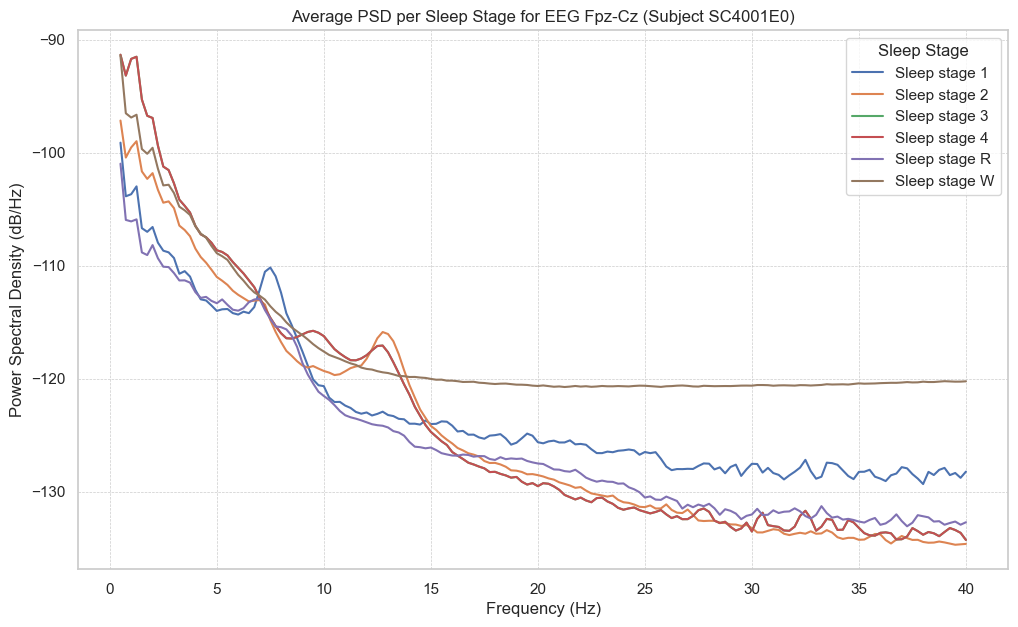


Processing PSD per sleep stage for Subject: SC4002E0
Extracted 2830 events. Stages present: ['Movement time', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage ?', 'Sleep stage R', 'Sleep stage W']
Created 2829 epochs.
Computing PSD for all 2829 epochs using channel 'EEG Fpz-Cz'...
PSD computed for all epochs. Shape: (2829, 159)


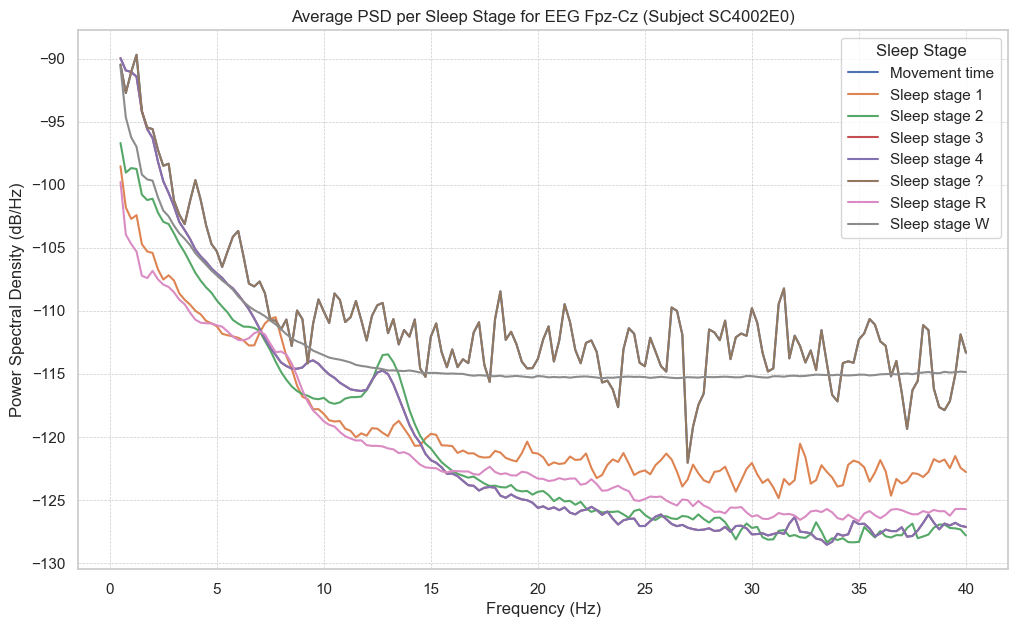


Processing PSD per sleep stage for Subject: SC4011E0
Extracted 2802 events. Stages present: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Created 2801 epochs.
Computing PSD for all 2801 epochs using channel 'EEG Fpz-Cz'...
PSD computed for all epochs. Shape: (2801, 159)


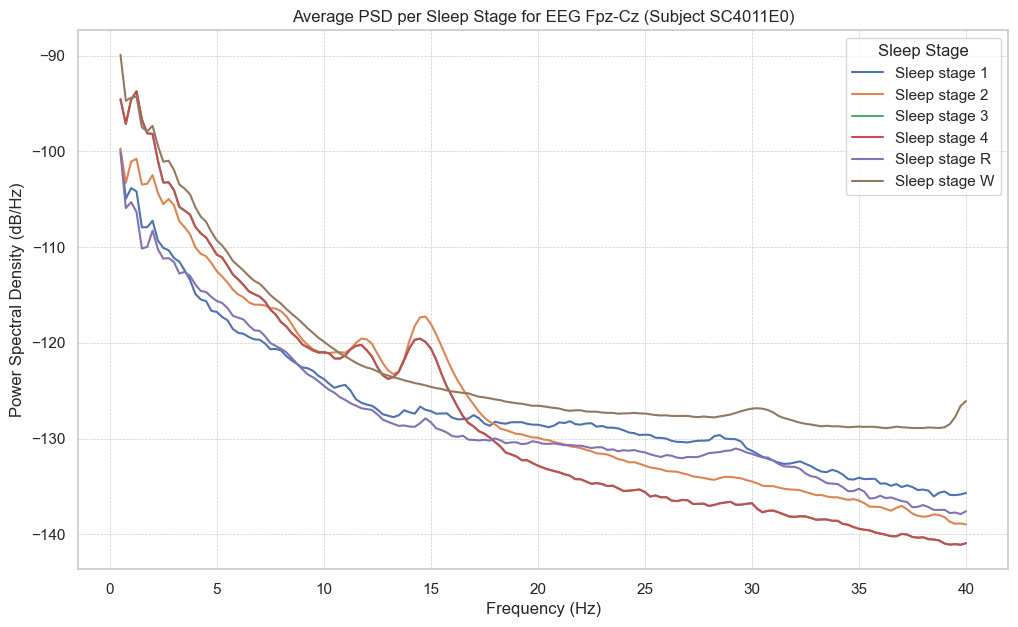


Processing PSD per sleep stage for Subject: ST7011J0
Extracted 1092 events. Stages present: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Created 1092 epochs.
Computing PSD for all 1092 epochs using channel 'EEG Fpz-Cz'...
PSD computed for all epochs. Shape: (1092, 159)


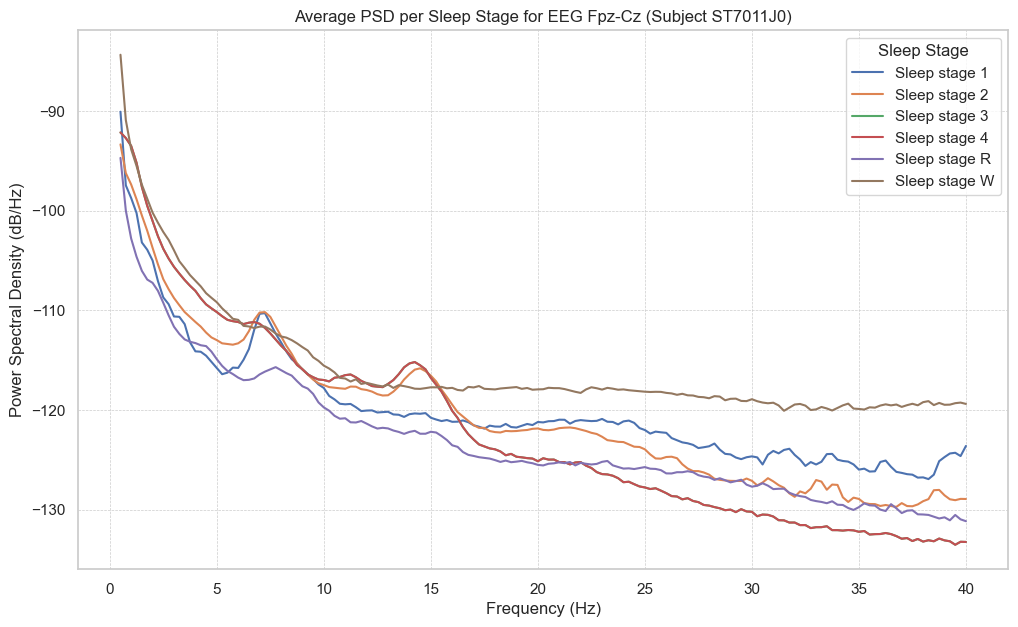


Processing PSD per sleep stage for Subject: ST7012J0
Extracted 1040 events. Stages present: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Created 1040 epochs.
Computing PSD for all 1040 epochs using channel 'EEG Fpz-Cz'...
PSD computed for all epochs. Shape: (1040, 159)


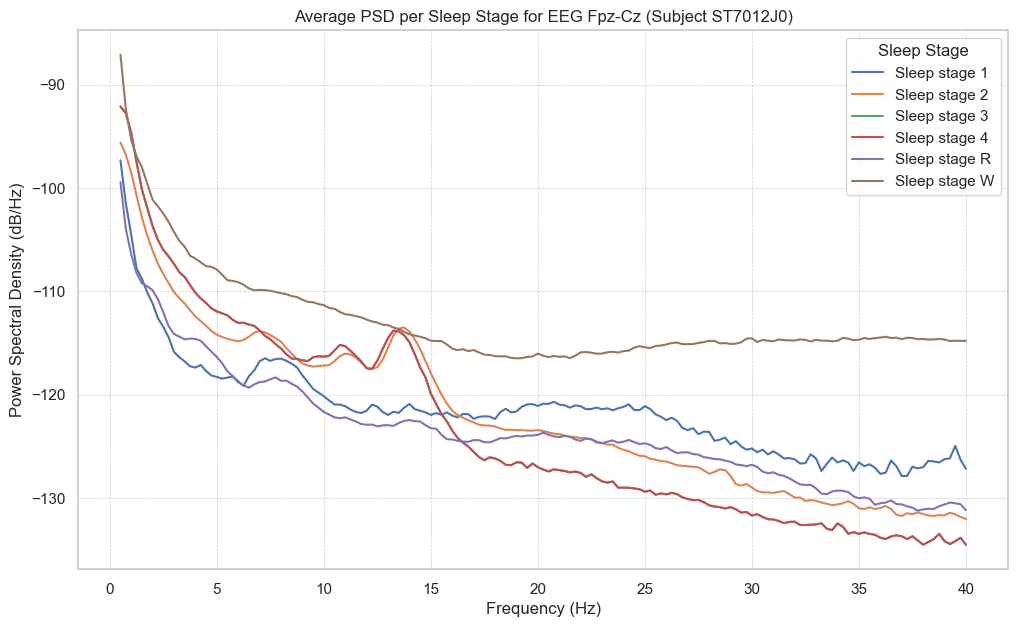


Processing PSD per sleep stage for Subject: ST7021J0
Extracted 920 events. Stages present: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Created 920 epochs.
Computing PSD for all 920 epochs using channel 'EEG Fpz-Cz'...
PSD computed for all epochs. Shape: (920, 159)


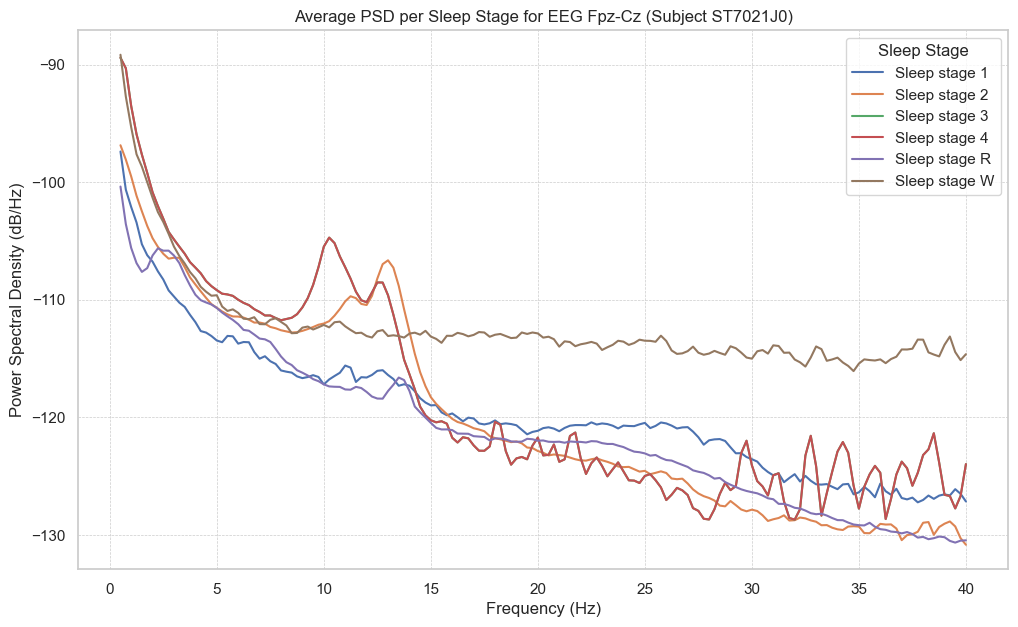

In [28]:
print("\n --- Plotting Average PSD per Sleep Stage ---")

event_id_mapping = {
    'Sleep stage W': 1, 'Sleep stage 1': 2, 'Sleep stage 2': 3,
    'Sleep stage 3': 4, 'Sleep stage 4': 4,
    'Sleep stage R': 5, 'Sleep stage ?': 6, 'Movement time': 6
}

all_epochs_data = {}

for i, raw in enumerate(all_subject_data):
    subject_id = raw.info.get('subject_info', {}).get('id', f'Unknown_{i}')
    print(f"\nProcessing PSD per sleep stage for Subject: {subject_id}")

    eeg_channel_name = None
    for ch_name in raw.ch_names:
        if 'EEG' in ch_name.upper():
            eeg_channel_name = ch_name
            break

    if not eeg_channel_name:
        print(f"No EEG channel found for {subject_id}. Skipping PSD per stage plot.")
        continue

    try:
        if raw.annotations is None or len(raw.annotations) == 0:
             print(f"  No annotations available for {subject_id}. Skipping event extraction.")
             events = None
             current_event_id = {}
        else:
             events, current_event_id = mne.events_from_annotations(
                 raw, event_id=event_id_mapping, chunk_duration=30.0,
             )
             # filter event_id dict to only include stages actually present in this subject
             unique_event_ids = np.unique(events[:, 2])
             current_event_id = {k: v for k, v in current_event_id.items() if v in unique_event_ids}
             print(f"Extracted {len(events)} events. Stages present: {list(current_event_id.keys())}")
    except ValueError as e:
        print(f"Warning: Could not extract events for {subject_id}: {e}")
        events = None
        current_event_id = {}
    except Exception as e_event:
        print(f"Error during event extraction for {subject_id}: {e_event}")
        events = None
        current_event_id = {}


    if events is not None and len(events) > 0 and current_event_id:
        # ensure data is loaded before epoching
        if not raw.preload:
             print(f"Preloading data for {subject_id}...")
             try:
                 raw.load_data()
                 print("  Data preloaded.")
             except Exception as e:
                 print(f"Error preloading data for {subject_id}: {e}. Skipping PSD per stage plot.")
                 continue

        try:
            epochs = mne.Epochs(raw, events, event_id=current_event_id, tmin=0., tmax=30.0,
                                baseline=None, preload=True, on_missing='warn')
            all_epochs_data[subject_id] = epochs
            print(f"Created {len(epochs)} epochs.")

            print(f"Computing PSD for all {len(epochs)} epochs using channel '{eeg_channel_name}'...")
            try:
                psd_all_epochs = epochs.compute_psd(
                    method='welch', n_fft=n_fft, n_overlap=n_fft // 2,
                    fmin=fmin, fmax=fmax,
                    picks=[eeg_channel_name], verbose=False
                )
                psd_data, freqs = psd_all_epochs.get_data(return_freqs=True)
                psd_data = psd_data[:, 0, :]
                print(f"PSD computed for all epochs. Shape: {psd_data.shape}")
            except Exception as e_psd_all:
                 print(f"Error computing PSD for all epochs: {e_psd_all}. Skipping PSD per stage plot.")
                 continue

            plt.figure(figsize=(12, 7))
            stages_plotted = False
            for stage_name, stage_id in current_event_id.items():
                try:
                    epoch_indices = np.where(epochs.events[:psd_data.shape[0], 2] == stage_id)[0]

                    if len(epoch_indices) > 0:
                        stage_psd_data = psd_data[epoch_indices, :]
                        mean_psd = np.mean(stage_psd_data, axis=0)

                        if np.any(np.isfinite(mean_psd)):
                            plt.plot(freqs, 10 * np.log10(mean_psd), label=f'{stage_name}')
                            stages_plotted = True
                        else:
                            print(f"Skipping plot for stage '{stage_name}' due to invalid PSD values after averaging.")
                    else:
                        print(f"No PSD data found for stage '{stage_name}' (Epoch indices length: {len(epoch_indices)}).")


                except IndexError as e_idx:
                     print(f"IndexError processing PSD for stage {stage_name}: {e_idx}. Check alignment between epochs.events and psd_data.")
                except Exception as e_psd_avg:
                    print(f"Error processing/averaging PSD for stage {stage_name}: {e_psd_avg}")

            if stages_plotted:
                 plt.title(f'Average PSD per Sleep Stage for {eeg_channel_name} (Subject {subject_id})')
                 plt.xlabel('Frequency (Hz)')
                 plt.ylabel('Power Spectral Density (dB/Hz)')
                 plt.legend(title="Sleep Stage")
                 plt.grid(True, which='both', linestyle='--', linewidth=0.5)
                 plt.show()
            else:
                 print(f"No valid stages were plotted for subject {subject_id}.")
                 plt.close()

        except Exception as e_epoch:
            print(f"Error creating epochs or processing PSD for {subject_id}: {e_epoch}")
            plt.close('all')
    else:
        print(f"Cannot plot PSD per stage for {subject_id}: Events not extracted or mapping failed.")


--- Aggregating Sleep Stage Counts Across Subjects ---


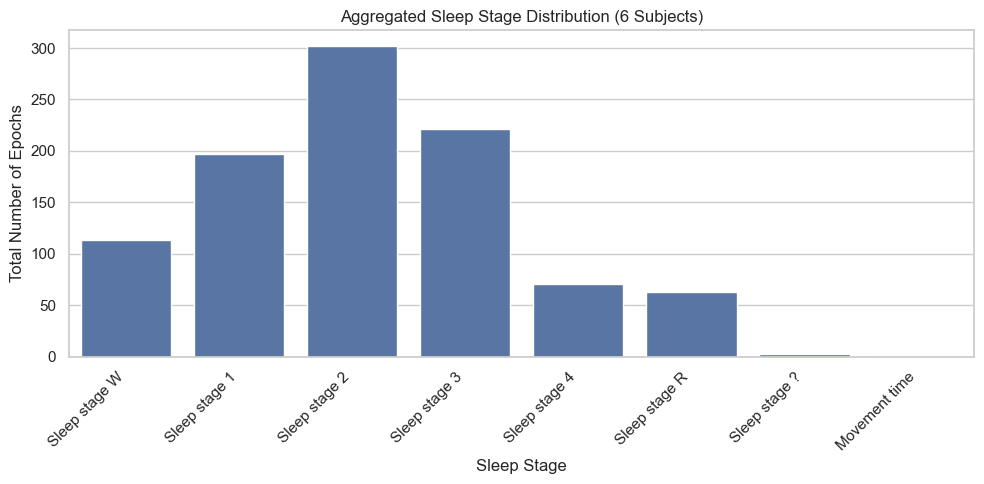


Aggregated Sleep Stage Counts:
Sleep stage W    113
Sleep stage 1    197
Sleep stage 2    302
Sleep stage 3    221
Sleep stage 4     71
Sleep stage R     63
Sleep stage ?      3
Movement time      1
dtype: int64


In [29]:
print("\n--- Aggregating Sleep Stage Counts Across Subjects ---")

all_stage_counts = pd.Series(dtype=int)

for subject_id, counts in all_annotations_summary.items():
    if not counts.empty:
        all_stage_counts = all_stage_counts.add(counts, fill_value=0)

stage_order = ['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage ?', 'Movement time']
all_stage_counts = all_stage_counts.reindex([s for s in stage_order if s in all_stage_counts.index]).astype(int)

if not all_stage_counts.empty:
    plt.figure(figsize=(10, 5)) # Create a new figure
    sns.barplot(x=all_stage_counts.index, y=all_stage_counts.values)
    plt.title(f'Aggregated Sleep Stage Distribution ({len(all_subject_data)} Subjects)')
    plt.xlabel('Sleep Stage')
    plt.ylabel('Total Number of Epochs')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show() # Show plot

    print("\nAggregated Sleep Stage Counts:")
    print(all_stage_counts)
else:
    print("Cannot plot aggregated stage distribution: No annotation counts found.")


--- Generating Aggregated Dimensionality Reduction Plots ---
Generating simple features for 6 subjects...
  Processing 2649 epochs for subject SC4001E0...
  Processing 2829 epochs for subject SC4002E0...
  Processing 2801 epochs for subject SC4011E0...
  Processing 1092 epochs for subject ST7011J0...
  Processing 1040 epochs for subject ST7012J0...
  Processing 920 epochs for subject ST7021J0...

Extracted 11331 total valid epochs with 6 simple features.
Feature names: ['Mean Amp', 'Std Dev', 'Delta', 'Theta', 'Alpha', 'Beta']
Running PCA on aggregated features...
Explained variance ratio by PCA components: [0.84514983 0.15485017]


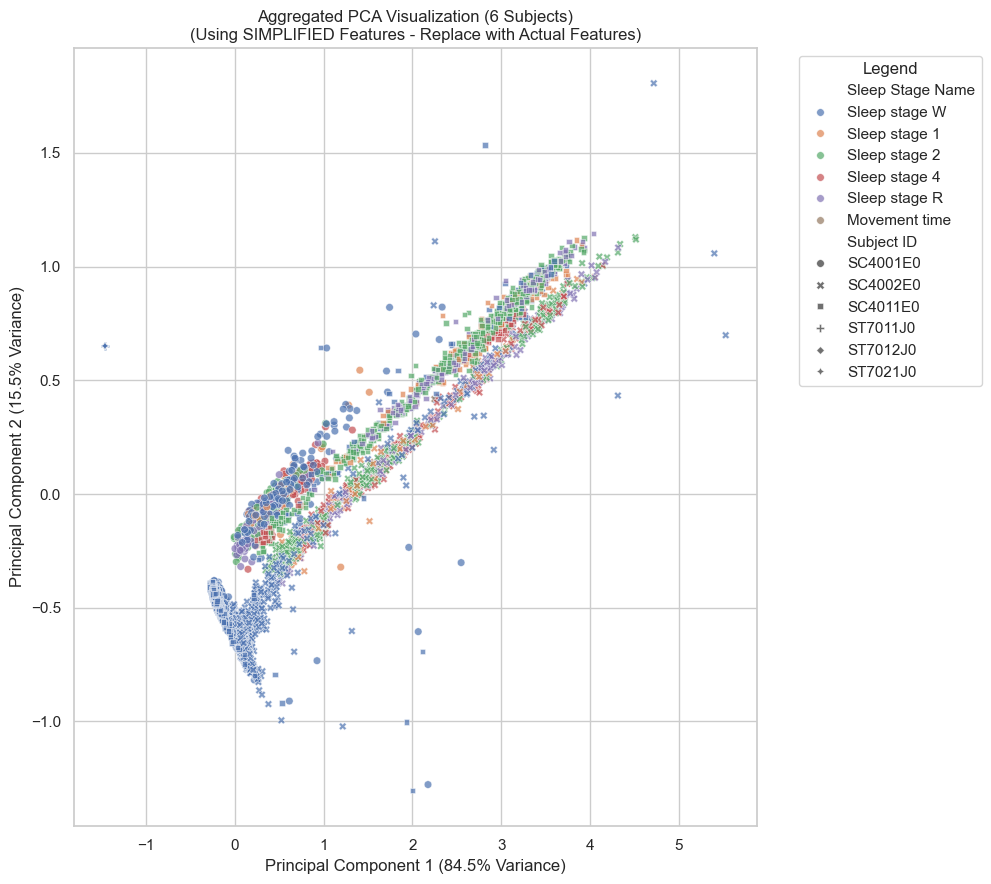


Running t-SNE on aggregated features...
(This may take a while depending on the number of epochs...)


/Users/mede/anaconda3/envs/AML/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE finished in 7.33 seconds.


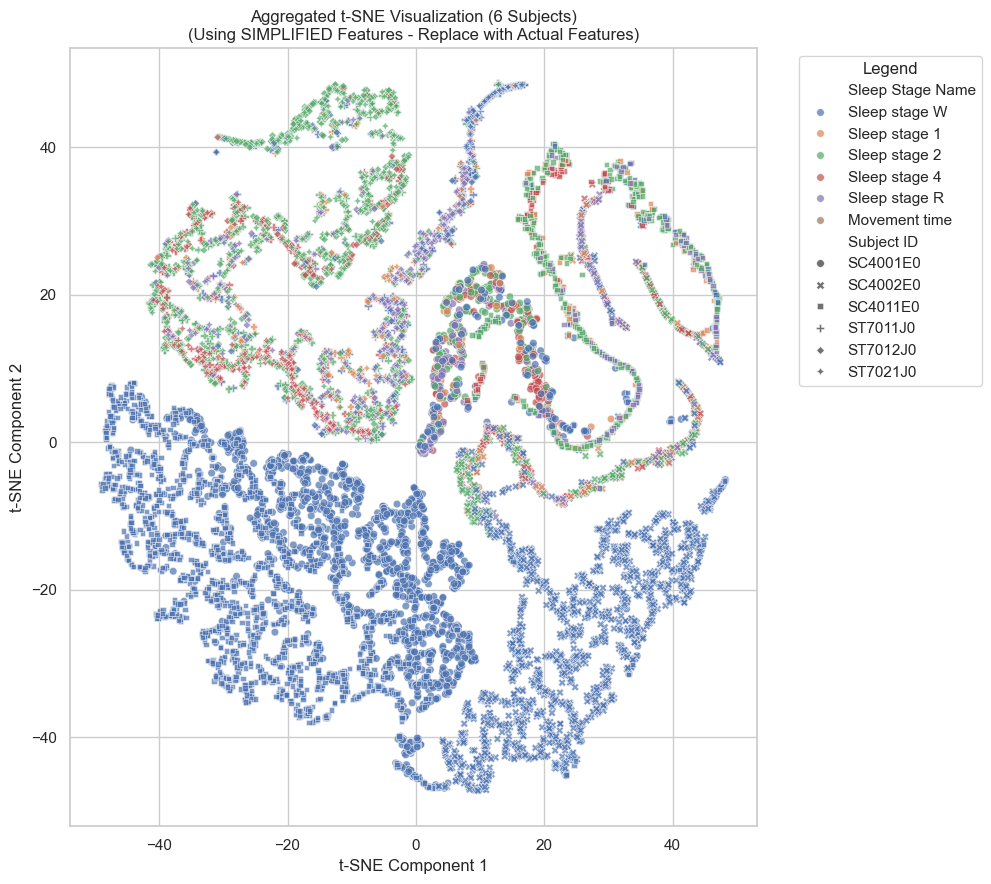

In [35]:
import time
from sklearn.preprocessing import StandardScaler


print("\n--- Generating Aggregated Dimensionality Reduction Plots ---")

all_simple_features = []
all_epoch_labels = []
all_subject_ids_for_dim_red = []

bands = {"Delta": (0.5, 4.0), "Theta": (4.0, 8.0), "Alpha": (8.0, 13.0), "Beta": (13.0, 30.0)}

if not all_epochs_data:
     print("Epochs data not available for Dimensionality Reduction (check previous steps for errors). Skipping.")
     features_array = None
else:
    print(f"Generating simple features for {len(all_epochs_data)} subjects...")
    for subject_id, epochs in all_epochs_data.items():
        print(f"  Processing {len(epochs)} epochs for subject {subject_id}...")
        if len(epochs) == 0: continue

        eeg_picks = mne.pick_types(epochs.info, eeg=True)
        if not eeg_picks.size > 0:
            print(f"No EEG channels found for {subject_id}. Skipping feature extraction.")
            continue

        for i in range(len(epochs)):
            try:
                epoch_data = epochs[i].get_data(picks='eeg')
                if epoch_data.size == 0: continue

                mean_amp = np.mean(np.abs(epoch_data)) * 1e6
                std_dev = np.mean(np.std(epoch_data, axis=-1)) * 1e6

                try:
                     sfreq_epoch = epochs.info['sfreq']
                     n_fft_epoch = int(4 * sfreq_epoch)
                     psd_vals, freqs = mne.time_frequency.psd_array_welch(
                         epoch_data, sfreq=sfreq_epoch, fmin=0.5, fmax=30.0,
                         n_fft=n_fft_epoch, n_overlap=n_fft_epoch // 2, average='mean',
                         verbose=False
                     )
                     psd_vals = np.mean(psd_vals, axis=0)

                except Exception as e_psd_feat:
                     print(f"Warning: Could not compute PSD for epoch {i} of {subject_id}: {e_psd_feat}. Using zeros for band power.")
                     n_times = epoch_data.shape[-1]
                     freqs = np.fft.rfftfreq(n_times, d=1./sfreq_epoch)
                     psd_vals = np.zeros_like(freqs)

                band_powers = []
                for fmin_band, fmax_band in bands.values():
                     valid_mask = (freqs >= fmin_band) & (freqs < fmax_band)
                     if np.any(valid_mask) and psd_vals.shape == freqs.shape:
                         power = np.mean(psd_vals[valid_mask])
                         band_powers.append(power if np.isfinite(power) else 0)
                     else:
                         band_powers.append(0)

                current_features = [mean_amp, std_dev] + band_powers
                if not np.all(np.isfinite(current_features)):
                    print(f"Warning: NaN/Inf found in features for epoch {i} of {subject_id}. Skipping epoch.")
                    continue

                all_simple_features.append(current_features)
                all_epoch_labels.append(epochs.events[i, 2])
                all_subject_ids_for_dim_red.append(subject_id)
            except Exception as e_feat:
                 print(f"Error extracting features for epoch {i} of subject {subject_id}: {e_feat}")

    if all_simple_features:
        features_array = np.array(all_simple_features)
        if features_array.shape[0] == 0:
             print("\nNo valid features extracted for Dim. Reduction after filtering.")
             features_array = None
        else:
             scaler = StandardScaler()
             features_scaled = scaler.fit_transform(features_array)

             print(f"\nExtracted {features_scaled.shape[0]} total valid epochs with {features_scaled.shape[1]} simple features.")
             feature_names = ['Mean Amp', 'Std Dev'] + list(bands.keys())
             print(f"Feature names: {feature_names}")

             # PCA
             print("Running PCA on aggregated features...")
             pca = PCA(n_components=2)
             features_pca = pca.fit_transform(features_scaled)
             print(f"Explained variance ratio by PCA components: {pca.explained_variance_ratio_}")

             pca_df = pd.DataFrame(features_pca, columns=['PC1', 'PC2'])
             pca_df['Sleep Stage ID'] = all_epoch_labels[:features_array.shape[0]]
             pca_df['Subject ID'] = all_subject_ids_for_dim_red[:features_array.shape[0]]
             id_to_name_map_pca = {v: k for k, v in event_id_mapping.items()}
             pca_df['Sleep Stage Name'] = pca_df['Sleep Stage ID'].map(id_to_name_map_pca).fillna('Unknown')

             plt.figure(figsize=(12, 9))
             sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Sleep Stage Name', style='Subject ID', s=30, alpha=0.7)

             plt.title(f'Aggregated PCA Visualization ({len(all_epochs_data)} Subjects)\n'
                       f'(Using SIMPLIFIED Features - Replace with Actual Features)')
             plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
             plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
             plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
             plt.grid(True)
             plt.tight_layout(rect=[0, 0, 0.85, 1])
             plt.show()

             # t-SNE
             print("\nRunning t-SNE on aggregated features...")
             print("(This may take a while depending on the number of epochs...)")
             tsne_perplexity = min(30, max(5, features_scaled.shape[0] // 100))
             tsne_n_iter = 500

             tsne_start_time = time.time()
             tsne = TSNE(n_components=2, random_state=42, perplexity=tsne_perplexity, n_iter=tsne_n_iter, init='pca', learning_rate='auto')
             features_tsne = tsne.fit_transform(features_scaled)
             tsne_end_time = time.time()
             print(f"t-SNE finished in {tsne_end_time - tsne_start_time:.2f} seconds.")

             tsne_df = pd.DataFrame(features_tsne, columns=['TSNE1', 'TSNE2'])
             tsne_df['Sleep Stage ID'] = pca_df['Sleep Stage ID']
             tsne_df['Subject ID'] = pca_df['Subject ID']
             tsne_df['Sleep Stage Name'] = pca_df['Sleep Stage Name']

             plt.figure(figsize=(12, 9))
             sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Sleep Stage Name', style='Subject ID', s=30, alpha=0.7)

             plt.title(f'Aggregated t-SNE Visualization ({len(all_epochs_data)} Subjects)\n'
                       f'(Using SIMPLIFIED Features - Replace with Actual Features)')
             plt.xlabel('t-SNE Component 1')
             plt.ylabel('t-SNE Component 2')
             plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
             plt.grid(True)
             plt.tight_layout(rect=[0, 0, 0.85, 1])
             plt.show()

    else:
        print("\nCould not generate dimensionality reduction plots: No simple features extracted.")


--- Generating Overlap Visualization Plot (using PCA results) ---
Number of Wake/Movement epochs: 6112
Number of Other Sleep epochs: 5219


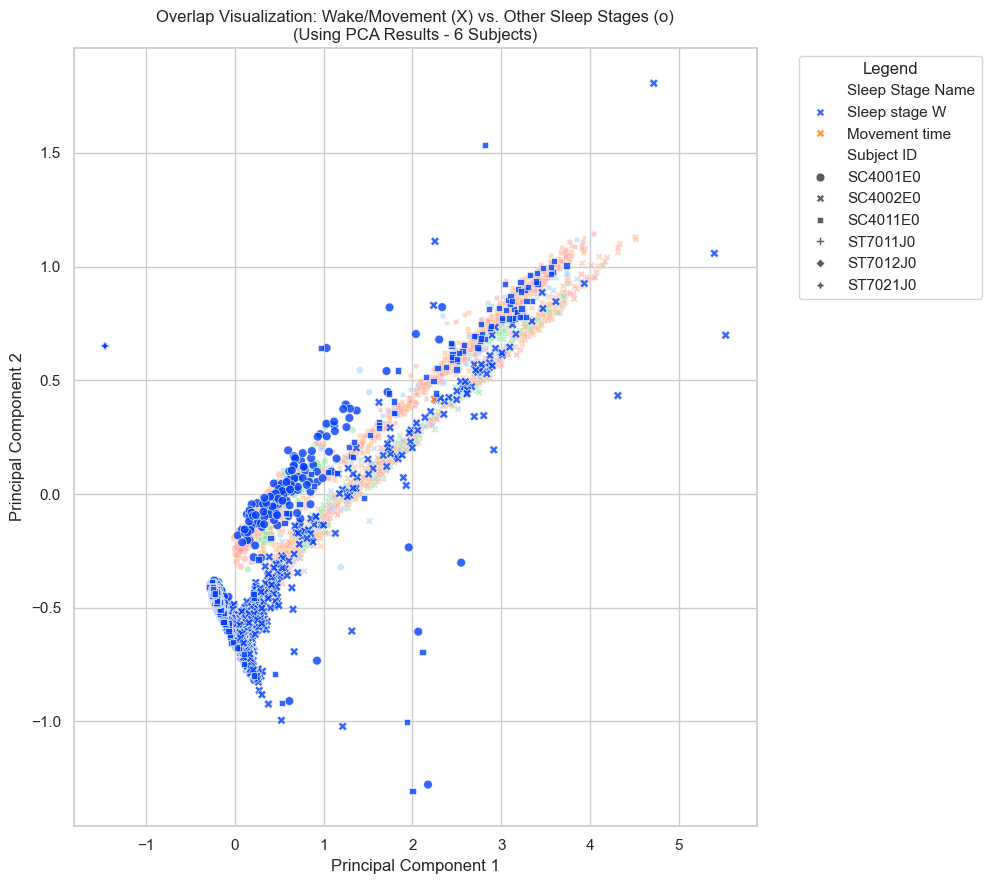

In [ ]:
print("\n--- Generating Overlap Visualization Plot (using PCA results) ---")

if 'pca_df' in locals() and isinstance(pca_df, pd.DataFrame) and not pca_df.empty:

    wake_movement_stages = ['Sleep stage W', 'Movement time']
    other_sleep_stages = ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 4', 'Sleep stage R']

    df_wake_move = pca_df[pca_df['Sleep Stage Name'].isin(wake_movement_stages)].copy()
    df_other_sleep = pca_df[pca_df['Sleep Stage Name'].isin(other_sleep_stages)].copy()

    print(f"Number of Wake/Movement epochs: {len(df_wake_move)}")
    print(f"Number of Other Sleep epochs: {len(df_other_sleep)}")

    if len(df_wake_move) == 0 and len(df_other_sleep) == 0:
         print("No data points found for Wake/Movement or Other Sleep stages. Skipping overlap plot.")
    else:
        plt.figure(figsize=(12, 9))

        sns.scatterplot(data=df_other_sleep, x='PC1', y='PC2',
                        hue='Sleep Stage Name',
                        style='Subject ID',
                        s=25, alpha=0.5,
                        palette='pastel',
                        legend=False
                       )

        sns.scatterplot(data=df_wake_move, x='PC1', y='PC2',
                        hue='Sleep Stage Name',
                        style='Subject ID',
                        s=40, alpha=0.8,
                        palette='bright',
                        marker='X'
                       )

        plt.title(f'Overlap Visualization: Wake/Movement (X) vs. Other Sleep Stages (o)\n'
                  f'(Using PCA Results - {len(all_epochs_data)} Subjects)')
        plt.xlabel(f'Principal Component 1')
        plt.ylabel(f'Principal Component 2')
        plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()

else:
    print("PCA results (pca_df) not available. Skipping overlap plot.")